In [1]:
import pandas as pd
df = pd.read_csv("sales_clean.csv")

In [2]:
df.head()

,order_id,date,product,price,qty,zip
0,1254,2026-04-06,mug,11.36,4,60614
1,1057,2026-05-30,charger,14.79,3,30303
2,1150,2026-05-06,mug,5.50,1,10001
3,1066,2026-05-30,notebook,37.53,1,98101
4,1114,2026-04-06,webcam,45.59,4,90405


In [3]:
df.shape

(292, 6)

In [4]:
df . info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292 entries, 0 to 291
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   order_id  292 non-null    int64  
 1   date      292 non-null    object 
 2   product   292 non-null    object 
 3   price     292 non-null    float64
 4   qty       292 non-null    int64  
 5   zip       292 non-null    int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 13.8+ KB


In [5]:
df.describe()

,order_id,price,qty,zip
count,292.000000,292.000000,292.000000,292.000000
mean,1145.500000,55.523151,2.910959,45463.989726
std,84.437354,71.767085,1.559457,39284.386854
min,1000.000000,2.930000,-5.000000,2116.000000
25%,1072.750000,11.045000,2.000000,2134.000000
50%,1145.500000,37.530000,3.000000,30303.000000
75%,1218.250000,55.510000,4.000000,90210.000000
max,1291.000000,479.290000,5.000000,98101.000000


In [6]:
print(df["price"].mean())
print(df["price"].median())
print(df["price"].std())

55.52315068493151
37.53
71.76708493504135


In [7]:
print(df["qty"].mean())
print(df["qty"].median())
print(df["qty"].std())

2.910958904109589
3.0
1.559457271336151


For price the mean is 55.52 and median is 37.53 The mean is noticeably higher than the median. I would report the median 37.53 because  the mean is slightly skewed by the max price of 479.29.

Text(0.5, 1.0, 'Distribution of Product Prices')

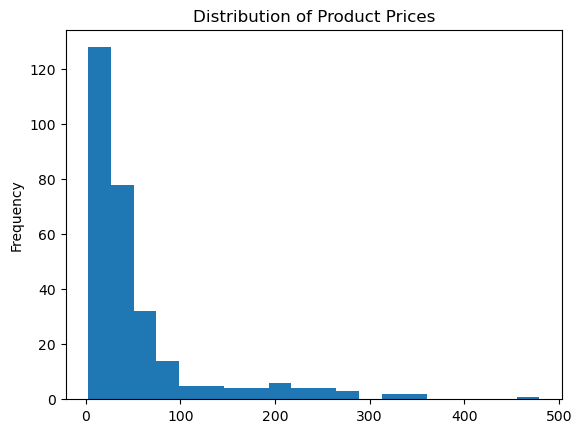

In [8]:
df["price"].plot(kind="hist", bins=20).set_title("Distribution of Product Prices")

The shape of the histogram is right-skewed (positive) because most products are on the lower end, while a few expensive products create a long tail to the right. 

In [9]:
df["revenue"] = df["price"] * df["qty"]

In [10]:
df.head()

,order_id,date,product,price,qty,zip,revenue
0,1254,2026-04-06,mug,11.36,4,60614,45.44
1,1057,2026-05-30,charger,14.79,3,30303,44.37
2,1150,2026-05-06,mug,5.50,1,10001,5.50
3,1066,2026-05-30,notebook,37.53,1,98101,37.53
4,1114,2026-04-06,webcam,45.59,4,90405,182.36


In [11]:
df.corr(numeric_only=True)

,order_id,price,qty,zip,revenue
order_id,1.000000,-0.005070,0.024140,-0.014784,0.005711
price,-0.005070,1.000000,-0.023683,0.023812,0.817699
qty,0.024140,-0.023683,1.000000,0.074617,0.334196
zip,-0.014784,0.023812,0.074617,1.000000,0.044615
revenue,0.005711,0.817699,0.334196,0.044615,1.000000


Although step 6 says qty vs. revenue should be the standout, my results show that price vs.revenue has a stronger correlation. Qty vs. revenue has a Pearson's r= 0.3342, while price vs.revenue is 0.8177.

Text(0.5, 1.0, 'Quantity vs. Revenue')

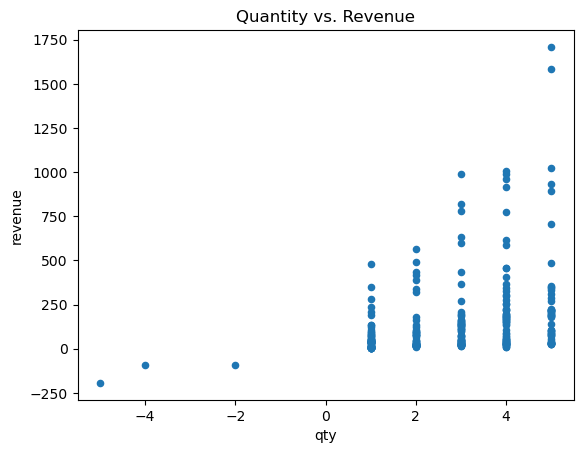

In [12]:
df.plot.scatter(x="qty", y="revenue") .set_title("Quantity vs. Revenue")

Text(0.5, 1.0, 'Price vs. Revenue')

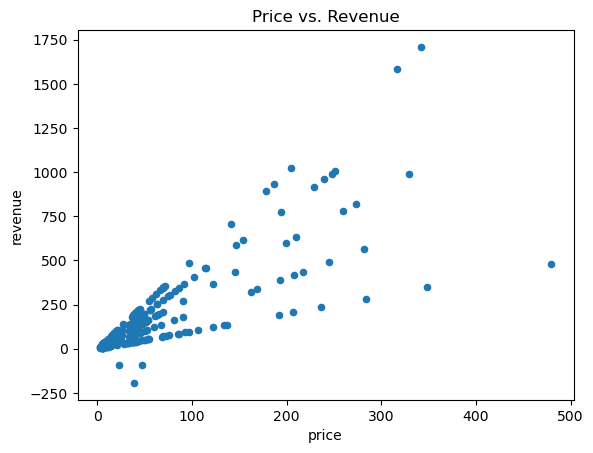

In [13]:
df.plot.scatter(x="price", y="revenue").set_title("Price vs. Revenue")

The quantity vs revenue scatter plot as an upward-drifting cloud, indicating a weak positive relationship. However the points are widely scattered, which supports the Pearson's r of 0.3342. The price vs revenue scatter plot shows a stronger postive relationship, which supports the Pearson's r of 0.8177. One caution is that a few high-priced products with very high revenue can influence the correlation.

### By-hand check
[2, 4, 4, 6, 9]  
Mean = (2+4+4+6+9)/5 = 25/5 =5

Median = 4, the middle number is 4

In [14]:
# Created a pandas Series to verify my calculations
num = pd.Series( [2, 4, 4, 6, 9])
print(num.mean())
print(num.median())

5.0
4.0



Git Hub Link: https://github.com/jazzminowens/cs82a-portfolio